In [1]:
# Author: Ethan Stroberg
# National Severe Storms Laboratory
# This code last updated on October 15, 2025
#
# Version 1.6.1 - removed Gaussian Naive Bayes, it sucked
# Version 1.6 - adding plots that visualize classificaions vs variables
# Version 1.5 - added T, RH, and P data from .csv and .txt files, includes addition of functions
# Version 1.4 - updated to give a user-based description of classifications
# Version 1.3 - updated to only use majority rules cases, normalized dataset
# Verison 1.2 - added machine learning models
# Version 1.1 - updated to only take in values classified as 2 or less
# Version 1.0 - original code written by Mike to read in data and plot histograms
#
# finally decided to keep track of the versions lol, I think this is somewhat how it's gone (- me 2/20)


In [ ]:
#imports
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score
import sklearn
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.ndimage import gaussian_filter1d
import pyart                                   # Used to read, work with, and save modified versions of radar data
from csu_radartools import (csu_fhc, csu_kdp)  # CSU Radar Tools contains several different functions. KDP and HID functions used within this notebook example.
import matplotlib.pyplot as plt                # Use the pyplot method of the matplotlib package - read it in as a "shortcut"
import matplotlib.colors as colors             # Use the colors method of the matplotlib package - read it in as a "shortcut"
import copy                                    # Enable copying vs. linking of existing variables
import numpy as np                             # Use numpy package (abbreviated as np)
import numpy.ma as ma                          # Use numpy's masked array capabilities (abbreviated as ma)
import datetime as dt                          # Format time as datetime instances
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import nexradaws
import glob
from scipy import spatial
conn = nexradaws.NexradAwsInterface()
warnings.filterwarnings('ignore')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [3]:
# create any relevant functions
# frame_extractor: extracts the image frame from the list of filenames in the IOP10 file
def frame_extractor(filename):
    parts = filename.split('_')
    frame_number = parts[-1].split('.')[0]
    return frame_number

# time_extractor: extracts the time of day from the list of filenames in the IOP10 file and converts to HH:MM:SS format
def time_extractor(filename):
    parts = filename.split('_')
    time_list = parts[0].split('-')[-3:]
    time_colon_format = ":".join(map(str, time_list))
    return time_colon_format

In [4]:
#read in the file
hdfFile = h5py.File('pasive_manualclassification_condensed2.h5', 'r')

#create dictionary to store the data
particleTable = {}
print('Reading in hdf5 file')

#list all keys in the file
hdfKeys = list(hdfFile.keys())
N = len(hdfKeys)
# create a list of hdfKeys that will be added to the dataframe later
valid_keys = []

for i, key in enumerate(hdfKeys):
    dset = hdfFile[key]

    #check the 'classifications' attribute
    if 'classifications' in dset.attrs:
        classifications = dset.attrs['classifications']

        valueCount = [0,0,0]
        for user, value in classifications:
            if value <= 2:
                valueCount[value] += 1

        majority = np.argmax( valueCount )

        #check to see that there isn't a tie
        maxCount = 0
        for count in valueCount:
            if count == max( valueCount ): maxCount += 1
        if maxCount != 1:
            #there is a tie, that's not good
            continue
        
        # add each valid key to the list for the dataframe later
        valid_keys.append(key)

        for attr in dset.attrs:
            if attr not in particleTable:
                particleTable[attr] = []
            if attr == 'classifications':
                #we already filtered these, we handle this special
                particleTable[attr].append( majority )
            else:
                particleTable[attr].append(dset.attrs[attr])   
    else:
        #there isn't a classification for this particle, wack
        #probably we don't need this else because we're at the end of the loop
        continue     
    
print(f"Filtered data has been loaded into particleTable with {len(particleTable)} attributes.")

Reading in hdf5 file
Filtered data has been loaded into particleTable with 31 attributes.


In [5]:
# print( particleTable.keys() )
# print( min(particleTable['image']), max(particleTable['image']),)

In [6]:
#for key in particleTable:
#    print( key.ljust(15), len( particleTable[key]) )

print( 'The following classifications were issued')
classificationCounts = {}
for value in particleTable['classifications']:
    if not value in classificationCounts:
        classificationCounts[value] = 0
    classificationCounts[value] += 1

classificationHeader = particleTable['classification_header'][0]
for key in classificationCounts:
    print( '%s %5i'%(classificationHeader[key], classificationCounts[key]) )

# for k in particleTable:
#     print ( k, len(particleTable[k]) )
print( len(hdfKeys))

The following classifications were issued
s 10389
i  1916
b  2102
15008


In [7]:
# Count how many times each user classified each classification

# make lists to store the number of times each user classified each type
count3195 = [0, 0, 0]
count3194 = [0, 0, 0]
count3225 = [0, 0, 0]
count3128 = [0, 0, 0]

for i, key in enumerate(hdfKeys):
    dset = hdfFile[key]
    if 'classifications' in dset.attrs:
        classifications = dset.attrs['classifications']
        for user, value in classifications:
            # if the value is allowed and fits a particular user, append that user's count list
            if value <= 2:
                if user == 3195:
                    count3195[value] += 1
                elif user == 3194:
                    count3194[value] += 1
                elif user == 3225:
                    count3225[value] += 1
                elif user == 3128:
                    count3128[value] += 1
                    
# calculate percentages for each user
#3195
snow3195 = count3195[0] / (count3195[0] + count3195[1] + count3195[2]) * 100
broken3195 = count3195[1] / (count3195[0] + count3195[1] + count3195[2]) * 100
ice3195 =count3195[2] / (count3195[0] + count3195[1] + count3195[2]) * 100
#3194
snow3194 = count3194[0] / (count3194[0] + count3194[1] + count3194[2]) * 100
broken3194 = count3194[1] / (count3194[0] + count3194[1] + count3194[2]) * 100
ice3194 =count3194[2] / (count3194[0] + count3194[1] + count3194[2]) * 100
#3225
snow3225 = count3225[0] / (count3225[0] + count3225[1] + count3225[2]) * 100
broken3225 = count3225[1] / (count3225[0] + count3225[1] + count3225[2]) * 100
ice3225 =count3225[2] / (count3225[0] + count3225[1] + count3225[2]) * 100
#3128
snow3128 = count3128[0] / (count3128[0] + count3128[1] + count3128[2]) * 100
broken3128 = count3128[1] / (count3128[0] + count3128[1] + count3128[2]) * 100
ice3128 =count3128[2] / (count3128[0] + count3128[1] + count3128[2]) * 100

print("Individual User Classifications:")
print(f"3195: {count3195}")
print(f"3194: {count3194}")
print(f"3225: {count3225}")
print(f"3128: {count3128}")
# reacall that 0-snow, 1-broken, 2-ice (I think right?  Double check with Mike or somethign because idk if I have i and b backwards)
print(f"Percentages for 3195 = {snow3195:.2f}% s, {broken3195:.2f}% b, {ice3195:.2f}% i")
print(f"Percentages for 3194 = {snow3194:.2f}% s, {broken3194:.2f}% b, {ice3194:.2f}% i")
print(f"Percentages for 3225 = {snow3225:.2f}% s, {broken3225:.2f}% b, {ice3225:.2f}% i")
print(f"Percentages for 3128 = {snow3128:.2f}% s, {broken3128:.2f}% b, {ice3128:.2f}% i")


Individual User Classifications:
3195: [6950, 1310, 1545]
3194: [9897, 2691, 2028]
3225: [7520, 1230, 1871]
3128: [289, 196, 265]
Percentages for 3195 = 70.88% s, 13.36% b, 15.76% i
Percentages for 3194 = 67.71% s, 18.41% b, 13.88% i
Percentages for 3225 = 70.80% s, 11.58% b, 17.62% i
Percentages for 3128 = 38.53% s, 26.13% b, 35.33% i


In [8]:
#This dataframe will contain all data essential to teaching the computer how to identify different classifications of precipitation
#It includes EVERY instance of a classification, so if a particular particle has three classifications, 
#that situation will appear three times, one for each classification

df = pd.DataFrame()
for k in [ 'BrightHist1', 'BrightHist2', 'BrightHist3', 'BrightHist4', 'BrightHist5', 'BrightHist6', 'BrightHist7', 'BrightHist8', 'BrightHist9', 'BrightHist10',
           'Bright_avg', 'Bright_count', 'Bright_max', 'Bright_median', 'classifications', 'e', 'irreg', 'maj', 'maxIrreg', 'min', 'minIrreg', 'prt', 'r']:
    df[k] = particleTable[k] 
#lets also add a column for the valid hdfKeys, but let's clean it up first
framekeys_HDF = [key.split('_')[0] for key in valid_keys]
df['Frame'] = framekeys_HDF
df.dropna() #this will drop any rows that have a missing value -> prevent any issues with data holes
# display(df)
# print(df.shape)

# Now let's bring in the NSSL csv data for Temperature and pressure HUZZAH
# read the csv into a dataframe
df_csv = pd.read_csv("NSSL1_MW41_output_20230201_185158.csv")
# convert the GPS Time Record row to a datetime object consisting only of the HHMMSS time (cleaner, no reason for a date)
# strip any leading or trailing whitespace
df_csv["GPS Time Record      "] = df_csv["GPS Time Record      "].str.strip() 
# establish current format and convert
df_csv["GPS Time Record      "] = pd.to_datetime(df_csv["GPS Time Record      "], format = '%d-%b-%Y %H:%M:%S')
df_csv['GPS Time Record      '] = df_csv['GPS Time Record      '].dt.strftime('%H:%M:%S')
df_csv.rename(columns={'GPS Time Record      ': 'GPS Time Record'}, inplace=True)
# print(df_csv.columns)
#display(df_csv)

# time to add the associated frame numbers to each time
# i'm thinking I'll add the first frame number for that instance because there are many frame numbers for each second
# first, lets open the txt file and read each line into a list of filenames
with open('IOP10_fileList.txt', 'r') as file:
    filenames = file.readlines()
#clean up the list and get rid of extra spaces
filenames = [filename.strip() for filename in filenames]

# extract the frames from the filenames
frame_numbers = [frame_extractor(filename) for filename in filenames]

# extract the time from the filenames and format it as HH:MM:SS
times = [time_extractor(filename) for filename in filenames]

# create the dataframe
frame_df = pd.DataFrame({'GPS Time Record': times, 'Frame': frame_numbers})

# 18:52:34 is #9489 in iop10, index 9490, need to match
frame_df = frame_df.drop(range(0, 9489))

# merge the NSSL file and IOP10 file dataframes based on the aligned timestamps --> add frames to the NSSL df
merged_df = pd.merge(df_csv, frame_df[['GPS Time Record', 'Frame',]], on='GPS Time Record', how='right')
merged_df.drop(0, axis = 0, inplace = True) # drop this first line because there were a handful of slightly anomalous values here
# display(merged_df)
# print(merged_df.shape)

# time for the big reveal.  please let this work
# merge the merged_df with the df of the HDF5 file data, merge using the keys/frame number
final_df = pd.merge(df, merged_df[['Filtered Temperature (K) ', 'Filtered Dewpoint (K) ', 'Filtered Pressure (mb) ', 'Frame', 'GPS Time Record', 'Filtered Altitude (m) ', 'Filtered Wind Spd (m/s) ', 'Calculated Mixing Ratio ']], on = 'Frame', how = 'inner')
final_df.drop(589, axis = 0, inplace = True) # had some nans
display(final_df)

,BrightHist1,BrightHist2,BrightHist3,BrightHist4,BrightHist5,BrightHist6,BrightHist7,BrightHist8,BrightHist9,BrightHist10,...,prt,r,Frame,Filtered Temperature (K),Filtered Dewpoint (K),Filtered Pressure (mb),GPS Time Record,Filtered Altitude (m),Filtered Wind Spd (m/s),Calculated Mixing Ratio
0,12.0,127.0,105.0,89.0,70.0,15.0,1.0,0.0,0.0,0.0,...,0,0.78,09491,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
1,19.0,320.0,359.0,297.0,163.0,94.0,14.0,0.0,0.0,0.0,...,3,1.36,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
2,9.0,206.0,387.0,306.0,278.0,300.0,255.0,108.0,9.0,0.0,...,9,1.66,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
3,8.0,190.0,209.0,136.0,78.0,11.0,0.0,0.0,0.0,0.0,...,14,0.96,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
4,2.0,70.0,199.0,117.0,89.0,37.0,4.0,0.0,0.0,0.0,...,39,0.88,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,0.0,1.0,24.0,49.0,35.0,30.0,5.0,0.0,0.0,0.0,...,3,0.45,15879,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975
12672,1.0,56.0,150.0,68.0,62.0,56.0,45.0,22.0,4.0,0.0,...,1,0.86,15881,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975
12673,1.0,84.0,164.0,142.0,67.0,28.0,2.0,0.0,0.0,0.0,...,0,0.83,15882,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975
12674,3.0,164.0,193.0,113.0,92.0,17.0,3.0,0.0,0.0,0.0,...,3,0.93,15883,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975


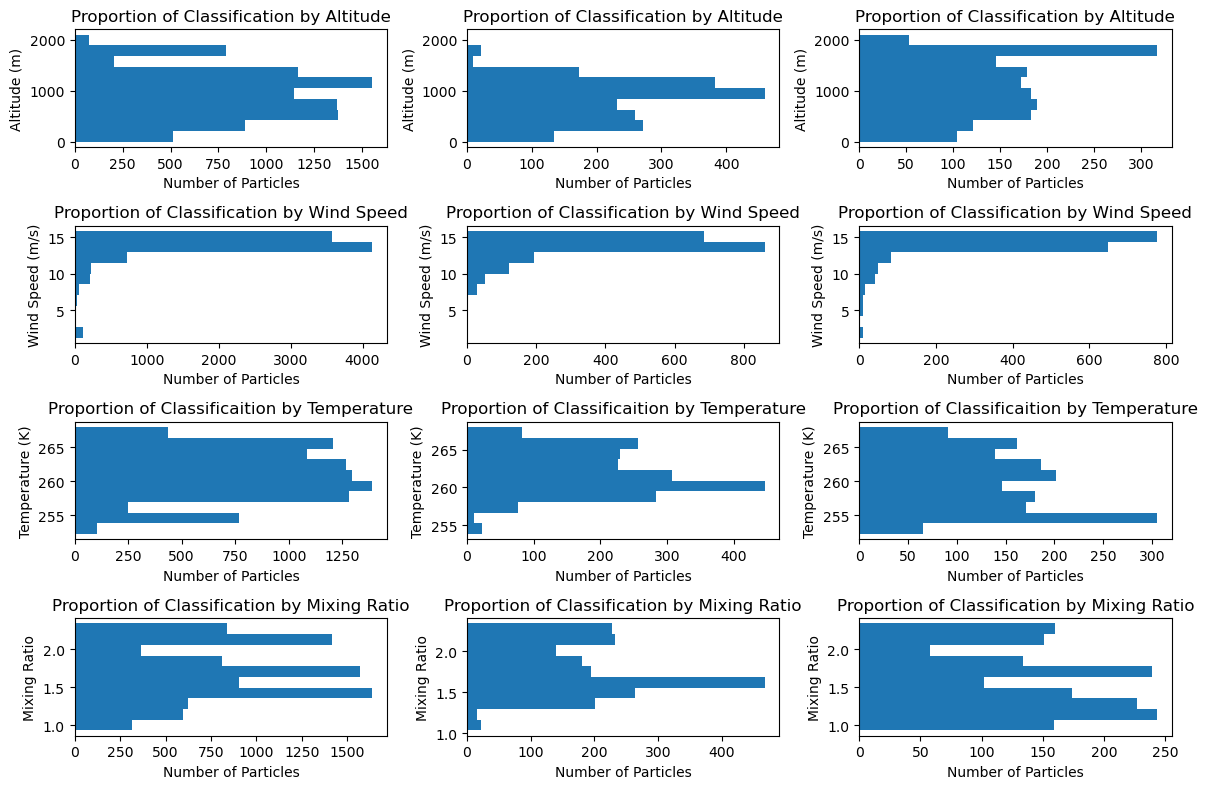

In [9]:
# lets do some more statistics and stuff
# plot altitude vs the classification given, see if there's a pattern as the sonde floated higher
# repeat for temp/RH as well

# filter out all but the desired classification for each dataframe
# dataframes for plotting classification v altitude
df_plot0 = final_df[final_df['classifications'] == 0]
df_plot1 = final_df[final_df['classifications'] == 1]
df_plot2 = final_df[final_df['classifications'] == 2]

# set label colors
#colors = ['aggregate snow', 'broken snow', 'ice']

# variable-specific datasets
alt_data0 = df_plot0['Filtered Altitude (m) ']
alt_data1 = df_plot1['Filtered Altitude (m) ']
alt_data2 = df_plot2['Filtered Altitude (m) ']

temp_data0 = df_plot0['Filtered Temperature (K) ']
temp_data1 = df_plot1['Filtered Temperature (K) ']
temp_data2 = df_plot2['Filtered Temperature (K) ']

wspd_data0 = df_plot0['Filtered Wind Spd (m/s) ']
wspd_data1 = df_plot1['Filtered Wind Spd (m/s) ']
wspd_data2 = df_plot2['Filtered Wind Spd (m/s) ']

mr_data0 = df_plot0['Calculated Mixing Ratio ']
mr_data1 = df_plot1['Calculated Mixing Ratio ']
mr_data2 = df_plot2['Calculated Mixing Ratio ']

dew_data0 = df_plot0['Filtered Dewpoint (K) ']
dew_data1 = df_plot1['Filtered Dewpoint (K) ']
dew_data2 = df_plot2['Filtered Dewpoint (K) ']

fig, ax = plt.subplots(nrows = 4, ncols = 3, figsize=(12, 8))
for axes in ax.flat:
    axes.set_xlabel('Number of Particles')
    #axes.legend(loc = 'upper right')

ax[0,0].hist(alt_data0, bins = 10, range = (0, 2100), orientation = 'horizontal', stacked = True )
ax[0,0].set_ylabel('Altitude (m)')
ax[0,0].set_title("Proportion of Classification by Altitude")

ax[1,0].hist(wspd_data0, bins = 10, orientation = 'horizontal', stacked = True)
ax[1,0].set_ylabel('Wind Speed (m/s)')
ax[1,0].set_title('Proportion of Classification by Wind Speed')

ax[2,0].hist(temp_data0, bins = 10, orientation = 'horizontal', stacked = True)
ax[2,0].set_ylabel('Temperature (K)')
ax[2,0].set_title('Proportion of Classificaition by Temperature')

ax[3,0].hist(mr_data0, bins = 10, orientation = 'horizontal', stacked = True)
ax[3,0].set_ylabel('Mixing Ratio')
ax[3,0].set_title('Proportion of Classification by Mixing Ratio')

ax[0,1].hist(alt_data1, bins = 10, range = (0, 2100), orientation = 'horizontal', stacked = True)
ax[0,1].set_ylabel('Altitude (m)')
ax[0,1].set_title("Proportion of Classification by Altitude")

ax[1,1].hist(wspd_data1, bins = 10, orientation = 'horizontal', stacked = True)
ax[1,1].set_ylabel('Wind Speed (m/s)')
ax[1,1].set_title('Proportion of Classification by Wind Speed')

ax[2,1].hist(temp_data1, bins = 10, orientation = 'horizontal', stacked = True)
ax[2,1].set_ylabel('Temperature (K)')
ax[2,1].set_title('Proportion of Classificaition by Temperature')

ax[3,1].hist(mr_data1, bins = 10, orientation = 'horizontal', stacked = True)
ax[3,1].set_ylabel('Mixing Ratio')
ax[3,1].set_title('Proportion of Classification by Mixing Ratio')

ax[0,2].hist(alt_data2, bins = 10, range = (0, 2100), orientation = 'horizontal', stacked = True)
ax[0,2].set_ylabel('Altitude (m)')
ax[0,2].set_title("Proportion of Classification by Altitude")

ax[1,2].hist(wspd_data2, bins = 10, orientation = 'horizontal', stacked = True)
ax[1,2].set_ylabel('Wind Speed (m/s)')
ax[1,2].set_title('Proportion of Classification by Wind Speed')

ax[2,2].hist(temp_data2, bins = 10, orientation = 'horizontal', stacked = True)
ax[2,2].set_ylabel('Temperature (K)')
ax[2,2].set_title('Proportion of Classificaition by Temperature')

ax[3,2].hist(mr_data2, bins = 10, orientation = 'horizontal', stacked = True)
ax[3,2].set_ylabel('Mixing Ratio')
ax[3,2].set_title('Proportion of Classification by Mixing Ratio')

fig.tight_layout()


In [10]:
#ok, let's machine learn
#first, we split the data into two categories: the inputs and the target variable
feature_cols = ['BrightHist1', 'BrightHist2', 'BrightHist3', 'BrightHist4', 'BrightHist5', 'BrightHist6', 'BrightHist7', 'BrightHist8', 'BrightHist9', 'BrightHist10', 
        'Bright_avg', 'Bright_count', 'Bright_max', 'Bright_median', 'e', 'irreg', 'maj', 'maxIrreg', 'min', 'minIrreg', 'r', 'Filtered Temperature (K) ',
        'Filtered Dewpoint (K) ', 'Filtered Pressure (mb) ']

X = final_df[['BrightHist1', 'BrightHist2', 'BrightHist3', 'BrightHist4', 'BrightHist5', 'BrightHist6', 'BrightHist7', 'BrightHist8', 'BrightHist9', 'BrightHist10', 
        'Bright_avg', 'Bright_count', 'Bright_max', 'Bright_median', 'e', 'irreg', 'maj', 'maxIrreg', 'min', 'minIrreg', 'r', 'Filtered Temperature (K) ',
        'Filtered Dewpoint (K) ', 'Filtered Pressure (mb) ']]
# TODO keep looking into using temp and dewpoint... the pool of cases is pretty small after all these datasets were merged... more may be needed
# TODO i removed 'prt' because if that's just the image particle number it should be pointless right?
y = final_df['classifications']

#in testing, I found that BrightHist2, 3, and 4 have "*****" string entries at some point, so we have to convert those to nan and drop them
#then, we make sure to rematch the y df to x so that they are the same length and play nice
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
y = y[X.index]

# print(X.shape)
# print(y.shape)

# Check for non-numeric entries in X --> this is where I found that some columns had strings hidden in there a few times
# def check_non_numeric(df):
#     for column in df.columns:
#         if not pd.to_numeric(df[column], errors='coerce').notna().all():
#             print(f"Non-numeric values found in column: {column}")

# check_non_numeric(X)

#now, we split the data into the training set and the testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# normalize the datasets to improve the algorithms
# possible scalers/transformers: StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer, QuantileTransformer, *PowerTransformer*
#PowerTransformer seems to give the highest overall accuracies, but Normalizer gives the absolute highest to RandomForest while hurting the others
# don't use min max bc it breaks SVM and doesn't classify any ice
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
###### Random Forest Model #######
# Create a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=140, random_state=42, bootstrap = True) #does bootstrap use replacement or no?

# Train the model on the training data
rf_classifier.fit(X_train_scaled, y_train)

# Make predictions on the testing data
rf_y_pred = rf_classifier.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, rf_y_pred)
print("Accuracy:", accuracy)

print("Classification Report: \n", classification_report(y_test, rf_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, rf_y_pred))

# now add the model predictions to a new row in final_df
# final_df['RF_Predictions'] = rf_classifier.predict(final_df[feature_cols])
X_full = final_df[feature_cols].apply(pd.to_numeric, errors='coerce')
valid_idx = X_full.dropna().index
X_full_scaled = scaler.transform(X_full.loc[valid_idx])

final_df.loc[valid_idx, 'RF_Predictions'] = rf_classifier.predict(X_full_scaled)


display(final_df)

Accuracy: 0.8334651898734177
Classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.94      0.90      1839
           1       0.82      0.52      0.63       394
           2       0.66      0.62      0.64       295

    accuracy                           0.83      2528
   macro avg       0.78      0.69      0.72      2528
weighted avg       0.83      0.83      0.83      2528

Confusion Matrix: 
 [[1721   43   75]
 [ 171  204   19]
 [ 110    3  182]]


,BrightHist1,BrightHist2,BrightHist3,BrightHist4,BrightHist5,BrightHist6,BrightHist7,BrightHist8,BrightHist9,BrightHist10,...,r,Frame,Filtered Temperature (K),Filtered Dewpoint (K),Filtered Pressure (mb),GPS Time Record,Filtered Altitude (m),Filtered Wind Spd (m/s),Calculated Mixing Ratio,RF_Predictions
0,12.0,127.0,105.0,89.0,70.0,15.0,1.0,0.0,0.0,0.0,...,0.78,09491,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260,0.0
1,19.0,320.0,359.0,297.0,163.0,94.0,14.0,0.0,0.0,0.0,...,1.36,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260,0.0
2,9.0,206.0,387.0,306.0,278.0,300.0,255.0,108.0,9.0,0.0,...,1.66,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260,0.0
3,8.0,190.0,209.0,136.0,78.0,11.0,0.0,0.0,0.0,0.0,...,0.96,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260,0.0
4,2.0,70.0,199.0,117.0,89.0,37.0,4.0,0.0,0.0,0.0,...,0.88,09495,267.9500,267.0068,1076.0000,18:52:34,67.2906,1.2000,2.24260,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12671,0.0,1.0,24.0,49.0,35.0,30.0,5.0,0.0,0.0,0.0,...,0.45,15879,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975,2.0
12672,1.0,56.0,150.0,68.0,62.0,56.0,45.0,22.0,4.0,0.0,...,0.86,15881,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975,0.0
12673,1.0,84.0,164.0,142.0,67.0,28.0,2.0,0.0,0.0,0.0,...,0.83,15882,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975,0.0
12674,3.0,164.0,193.0,113.0,92.0,17.0,3.0,0.0,0.0,0.0,...,0.93,15883,252.2203,252.2203,776.6438,18:57:54,2070.9936,13.0003,0.92975,0.0


In [12]:
###### Logistic Regression Model ######
#make the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

#make some predictions
LR_y_pred = model.predict(X_test_scaled)

#evaluate the model and print out some metrics/the results
accuracy = accuracy_score(y_test, LR_y_pred)
print("Accuracy = ", accuracy)

print("Classification Report: \n", classification_report(y_test, LR_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, LR_y_pred))

Accuracy =  0.803006329113924
Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.98      0.88      1839
           1       0.85      0.42      0.56       394
           2       0.76      0.24      0.36       295

    accuracy                           0.80      2528
   macro avg       0.80      0.54      0.60      2528
weighted avg       0.80      0.80      0.77      2528

Confusion Matrix: 
 [[1795   26   18]
 [ 225  165    4]
 [ 222    3   70]]


In [13]:
###### Support Vector Machines ######
#create a SVM classifier
classifier = svm.SVC(kernel='rbf', gamma=0.1, random_state=42) # rbf very slightly beats out poly, but but are essentially tied for the best
#0.7329700272479565
#train the model using the training sets
classifier.fit(X_train_scaled, y_train)
#Predict the response for test dataset
SVM_y_pred = classifier.predict(X_test_scaled)

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",accuracy_score(y_test, SVM_y_pred))
# Model Precision: what percentage of positive tuples are labeled as such?
#print("Precision:",precision_score(y_test, SVM_y_pred, average = 'micro'))
# Model Recall: what percentage of positive tuples are labelled as such?
#print("Recall:",recall_score(y_test, SVM_y_pred, average = 'micro'))
print("Classification Report: \n", classification_report(y_test, SVM_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, SVM_y_pred))

Accuracy: 0.7666139240506329
Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.99      0.86      1839
           1       0.89      0.28      0.43       394
           2       0.00      0.00      0.00       295

    accuracy                           0.77      2528
   macro avg       0.55      0.43      0.43      2528
weighted avg       0.69      0.77      0.69      2528

Confusion Matrix: 
 [[1826   13    0]
 [ 282  112    0]
 [ 294    1    0]]


In [14]:
###### K Nearest Neighbors Model ######
knn_model = KNeighborsClassifier(n_neighbors = 32, weights = 'distance') # n_neighbors = 32 is the highest I found || random state doesn't work here
knn_model.fit(X_train_scaled, y_train)
#make predictions on the test data
knn_y_pred = knn_model.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, knn_y_pred)
print("Accuracy:", accuracy)
print("Classification Report: \n", classification_report(y_test, knn_y_pred))

print("Confusion Matrix: \n", confusion_matrix(y_test, knn_y_pred))

Accuracy: 0.776503164556962
Classification Report: 
               precision    recall  f1-score   support

           0       0.78      0.97      0.86      1839
           1       0.88      0.37      0.52       394
           2       0.47      0.09      0.15       295

    accuracy                           0.78      2528
   macro avg       0.71      0.48      0.51      2528
weighted avg       0.76      0.78      0.73      2528

Confusion Matrix: 
 [[1789   19   31]
 [ 247  147    0]
 [ 267    1   27]]


# Alright, now that we have all the manual classification and ML predicting complete, we are going to attach all the radar processing below so that all data and variables needed for plotting are in the same notebook. #

In [15]:
#Define a function that removes individual 1D or 2D arrays of data corresponding to removed elevations
#This serves as a helper function for the following remove_sails function
#The function takes the index of the starting and ending values of the data in each elevation angle to be removed, 
#the array to be operated on, and the number of dimensions in the array
def remove_concatenate(start_ind, end_ind, data, array_dim=2):
    if array_dim == 2:
        h1 = data[:start_ind,:]
        h2 = data[end_ind+1:,:]
    if array_dim == 1:
        h1= data[:start_ind]
        h2 = data[end_ind+1:]
    new = ma.concatenate((h1,h2),axis=0)
    return new

#Define a function to identify all data corresponding to SAILS or the high-PRF elevation in a split-cut 
#sequence in super-res data. It's necessary to remove them in reverse order so that the count/index lists for 
#where elevations start and end remain correct and can be adjusted as needed.
#This function requires a Py-ART radar object as input
def remove_superres(original_radar):
    #Make a hard copy of the radar object being passed to the function - ensures that the original 
    #object will not be altered
    oradar = copy.deepcopy(original_radar)

    #Find the super-res (oversampled 0.5 degree azimuthal resolution) tilts that make up the split-cut and SAILS 
    #sequences (they will have 720 elements versus 360)
    start_inds = oradar.sweep_start_ray_index['data']
    end_inds = oradar.sweep_end_ray_index['data']
    num_azs = (end_inds-start_inds)+1      #Use the starting indices to get the number of azimuths in each elevation
    elevs = oradar.fixed_angle['data'] #Also, get a list of all elevation angles (will be used to find SAILS 
                                       #scans vs. super-res scans only)

    #SAILS and split-cut sequences are hi-res, have 720 azimuth data positions per sweep due to oversampling
    #To ID which sweeps to remove, isolate those with 720
    super_inds = np.where(num_azs == 720)[0]

    #Identify any added SAILS tilts (where fixed_angle < previous fixed_angle), collect these and the 
    #following scan (will be the 2nd in the super-res pair)
    sails1_ind = np.where(elevs[1:] < elevs[0:-1])[0]+1
    sails2_ind = []
    for l in sails1_ind:
        sails2_ind.append(l+1)
    sails2_ind = np.array(sails2_ind)
    sails_inds = np.sort(np.concatenate([sails1_ind,sails2_ind],axis=0))

    #Remove SAILS from super-res list
    for s in sails_inds:
        if s in super_inds: super_inds = np.setdiff1d(super_inds, np.array([s]))

    #Keep a list of sweeps to drop (every other of lowest set of super-res elevations; 
    #all others above the first normal-resolution elevation)
    drop_swps = []
    for ii, si in enumerate(super_inds):
        #Make sure to eliminate the second elevation in the set (corresponding to high PRF -> velocity data)
        if ii%2 == 1: drop_swps.append(si)
    #Remove remaining SAILS tilts 
    for ii, si in enumerate(sails_inds):
        drop_swps.append(si)

    #Reverse these to update the index lists from reverse (also, make sure they're sorted)
    drop_swps = np.array(list(reversed(drop_swps)))	

    #Extract unwanted data and reconstruct radar object information around each eliminated sweep
    #Start in reverse to preserve earlier index values for subtraction
    for a in drop_swps:

        #Get azimuth index values to remove for the specific elevation angle index
        si = oradar.sweep_start_ray_index['data'][a]
        ei = oradar.sweep_end_ray_index['data'][a]

        #1 Remove the 2D-shaped radar data based on azimuth (ZDR, PHI, RHO, etc. empty for high PRF sweeps) 
        #by calling pre-defined function
        field_names = list(oradar.fields.keys())
        for fn in field_names: oradar.fields[fn]['data'] = remove_concatenate(si,ei,oradar.fields[fn]['data'],array_dim=2)

        #2 Remove elements of 1D-shaped data (based only on azimuth dimension) by calling pre-defined function
        oradar.azimuth['data'] = remove_concatenate(si,ei,oradar.azimuth['data'],array_dim=1)
        oradar.elevation['data'] = remove_concatenate(si,ei,oradar.elevation['data'],array_dim=1)
        oradar.time['data'] = remove_concatenate(si,ei,oradar.time['data'],array_dim=1)
        oradar.instrument_parameters['unambiguous_range']['data'] = remove_concatenate(si,ei,oradar.instrument_parameters['unambiguous_range']['data'],array_dim=1)
        oradar.instrument_parameters['nyquist_velocity']['data'] = remove_concatenate(si,ei,oradar.instrument_parameters['nyquist_velocity']['data'],array_dim=1)

        #3 Remove elements of 1D-shaped data based on number of elevations (do not use pre-defined function)
        oradar.fixed_angle['data'] = ma.concatenate((oradar.fixed_angle['data'][:a],oradar.fixed_angle['data'][a+1:]),axis=0)	
        oradar.sweep_end_ray_index['data'] = ma.concatenate((oradar.sweep_end_ray_index['data'][:a],oradar.sweep_end_ray_index['data'][a+1:]),axis=0)	
        oradar.sweep_start_ray_index['data'] = ma.concatenate((oradar.sweep_start_ray_index['data'][:a],oradar.sweep_start_ray_index['data'][a+1:]),axis=0)	
        oradar.sweep_mode['data'] = ma.concatenate((oradar.sweep_mode['data'][:a],oradar.sweep_mode['data'][a+1:]),axis=0)	
        oradar.sweep_number['data'] = ma.concatenate((oradar.sweep_number['data'][:a],oradar.sweep_number['data'][a+1:]),axis=0)	

        #4 Adjust sweep start, end arrays based on number of elements removed
        diff = ei - si +1
        oradar.sweep_start_ray_index['data'][a:] = oradar.sweep_start_ray_index['data'][a:]-diff
        oradar.sweep_end_ray_index['data'][a:] = oradar.sweep_end_ray_index['data'][a:]-diff

    #5 Adjust the data that rely on count of azimuth angles or count of elevation angles
    oradar.nsweeps = len(oradar.fixed_angle['data'])
    oradar.nrays = len(oradar.azimuth['data'])

    #Return a new, adjusted radar object back from the function
    return oradar

#Define a function that gets the unmasked data from a radar field
#This can be thought of as a helper function for subsequent functions
#Copied from CSU radar tools example notebook on GitHub
#(https://github.com/CSU-Radarmet/CSU_RadarTools/blob/master/notebooks/CSU_RadarTools_Demo.ipynb)
def extract_unmasked_data(radar, field, bad=-32768):
    """Simplify getting unmasked radar fields from Py-ART"""
    return radar.fields[field]['data'].filled(fill_value=bad)

#Define a function that adds a new data field to a radar object with a similar format and attributes to
#those defined for other data fields
#Copied from CSU radar tools example notebook on GitHub
#(https://github.com/CSU-Radarmet/CSU_RadarTools/blob/master/notebooks/CSU_RadarTools_Demo.ipynb)
def add_field_to_radar_object(field, radar, field_name='HID', units='unitless', 
                              long_name='Hydrometeor Identification', 
                              standard_name='Hydrometeor ID',
                              dz_field='reflectivity'):
    """
    Adds a newly created field to the Py-ART radar object. If reflectivity is a masked array,
    make the new field masked the same as reflectivity.
    """
    fill_value = -32768
    masked_field = ma.asanyarray(field)
    masked_field.mask = masked_field == fill_value
    if hasattr(radar.fields[dz_field]['data'], 'mask'):
        setattr(masked_field, 'mask', np.logical_or(masked_field.mask, radar.fields[dz_field]['data'].mask))
        fill_value = radar.fields[dz_field]['_FillValue']
    field_dict = {'data': masked_field,
                  'units': units,
                  'long_name': long_name,
                  'standard_name': standard_name,
                  '_FillValue': fill_value}
    radar.add_field(field_name, field_dict, replace_existing=True)
    return radar

#Next set of defined functions copied from CSU Radar Tools GitHub example notebook
#The following 4 functions take sounding data and interpolate it to the same structure as the
#radar object (so that temperature is available at each data point)
#(https://github.com/CSU-Radarmet/CSU_RadarTools/blob/master/notebooks/CSU_RadarTools_Demo.ipynb)
def radar_coords_to_cart(rng, az, ele, debug=False):
    """
    TJL - taken from old Py-ART version
    Calculate Cartesian coordinate from radar coordinates
    Parameters
    ----------
    rng : array
        Distances to the center of the radar gates (bins) in kilometers.
    az : array
        Azimuth angle of the radar in degrees.
    ele : array
        Elevation angle of the radar in degrees.
    Returns
    -------
    x, y, z : array
        Cartesian coordinates in meters from the radar.
    Notes
    -----
    The calculation for Cartesian coordinate is adapted from equations
    2.28(b) and 2.28(c) of Doviak and Zrnic [1]_ assuming a
    standard atmosphere (4/3 Earth's radius model).
    .. math::
        z = \\sqrt{r^2+R^2+r*R*sin(\\theta_e)} - R
        s = R * arcsin(\\frac{r*cos(\\theta_e)}{R+z})
        x = s * sin(\\theta_a)
        y = s * cos(\\theta_a)
    Where r is the distance from the radar to the center of the gate,
    :math:\\theta_a is the azimuth angle, :math:\\theta_e is the
    elevation angle, s is the arc length, and R is the effective radius
    of the earth, taken to be 4/3 the mean radius of earth (6371 km).
    References
    ----------
    .. [1] Doviak and Zrnic, Doppler Radar and Weather Observations, Second
        Edition, 1993, p. 21.
    """
    theta_e = ele * np.pi / 180.0  # elevation angle in radians.
    theta_a = az * np.pi / 180.0  # azimuth angle in radians.
    R = 6371.0 * 1000.0 * 4.0 / 3.0  # effective radius of earth in meters.
    r = rng * 1000.0  # distances to gates in meters.

    z = (r ** 2 + R ** 2 + 2.0 * r * R * np.sin(theta_e)) ** 0.5 - R
    s = R * np.arcsin(r * np.cos(theta_e) / (R + z))  # arc length in m.
    x = s * np.sin(theta_a)
    y = s * np.cos(theta_a)
    return x, y, z


def get_z_from_radar(radar):
    """Input radar object, return z from radar (km, 2D)"""
    azimuth_1D = radar.azimuth['data']
    elevation_1D = radar.elevation['data']
    srange_1D = radar.range['data']
    sr_2d, az_2d = np.meshgrid(srange_1D, azimuth_1D)
    el_2d = np.meshgrid(srange_1D, elevation_1D)[1]
    xx, yy, zz = radar_coords_to_cart(sr_2d/1000.0, az_2d, el_2d)
    return zz + radar.altitude['data'] #Returns z AGL 

#Define a function to adjust color bars as needed to plot HID
def adjust_fhc_colorbar_for_pyart(cb):
    cb.set_ticks(np.arange(1.4, 10, 0.9))
    cb.ax.set_yticklabels(['Drizzle', 'Rain', 'Ice Crystals', 'Aggregates',
                           'Wet Snow', 'Vertical Ice', 'LD Graupel',
                           'HD Graupel', 'Hail', 'Big Drops/\nMelting Hail'])
    cb.ax.set_ylabel('')
    cb.ax.tick_params(length=0)
    return cb

#The following function takes a numeric HID score(s) and converts to a qualitative type
def convert_score_to_type(numeric_score):
    qual_category = {
        1: "Drizzle",
        2: "Rain",
        3: "Ice Crystals",
        4: "Aggregates",
        5: "Wet Snow",
        6: "Vertical Ice",
        7: "Low-Density Graupel",
        8: "High-Density Graupel",
        9: "Hail",
        10: "Big Drops/Melting Hail"
    }
    if isinstance(numeric_score,np.ndarray):
        output_category = []
        for ns in numeric_score:
            output_category.append(qual_category.get(ns, str(ns) +" is not a valid HID category index. Value must be in range of 1-10."))
    else: output_category = qual_category.get(numeric_score, str(numeric_score)+" is not a valid HID category index. Value must be in range of 1-10.")
    return output_category

#Add some HID plotting colors and labels (not strictly a function)
hid_type = ['Drizzle', 'Rain', 'Ice Crystals', 'Aggregates',
                           'Wet Snow', 'Vertical Ice', 'LD Graupel',
                           'HD Graupel', 'Hail', 'Big Drops/\nMelting Hail']

hid_colors = ['White', 'LightBlue', 'MediumBlue', 'DarkOrange', 'LightPink',
                'Cyan', 'DarkGray', 'Lime', 'Yellow', 'Red', 'Fuchsia']

cmaphid = colors.ListedColormap(hid_colors)

In [16]:
def grid_ground(ground, max_dist_from_radar=100e3):
    # Do the same for the ground
    des_tree_ground = spatial.KDTree(np.array([ground['x'],
                                               ground['y'],
                                               ground['alt above radar']]).T)
    gx = np.arange(-max_dist_from_radar,max_dist_from_radar,1e3)
    gx, gy = np.meshgrid(gx,gx)
    ground_lon, ground_lat = pyart.core.cartesian_to_geographic_aeqd(gx, gy,
                                                radar.longitude['data'][0], 
                                                radar.latitude['data'][0], 
                                                R=6370997.0)

    dist_g2, index_g2 = des_tree_ground.query(np.array([gx.ravel(), gy.ravel(),
                                            np.zeros_like(gx.ravel())]).T,
                                            k=1)

    ground_grid = np.array(ground['alt'])[index_g2].reshape(np.shape(gx))
    return gx, ground_lon, ground_lat, ground_grid, des_tree_ground

def cs_grid(radar, radar_tree, 
            min_x, max_x, min_y, max_y, spacing=0.1, vspacing=0.1):
    # Create cross section grid
    nn = int(((max_x-min_x)**2+(max_y-min_y)**2)**0.5/spacing) #100 m spacing
    des_x = np.linspace(min_x,max_x,nn)*1e3
    des_y = np.linspace(min_y,max_y,nn)*1e3
    des_z = np.arange(0,6,vspacing)*1e3
    new_x = np.arange(0,np.shape(des_x)[0]*0.1 ,spacing)*1e3
    desx_grid,desz_grid = np.meshgrid(des_x,des_z)
    desy_grid,desz_grid = np.meshgrid(des_y,des_z)

    edge_x = np.hstack((new_x- spacing/2, np.array([new_x[-1]+ spacing/2])))
    edge_z = np.hstack((des_z-vspacing/2, np.array([des_z[-1]+vspacing/2])))

    # Search tree for data points
    dists, indext = radar_tree.query(np.array([desx_grid.ravel(), 
                                        desy_grid.ravel(), 
                                        desz_grid.ravel()]).T)

    # Look for LMA sources near the radar grid points
    # Set 0,0 to be the left point of the cross-section
    # new_lma_x = lma_x_radar-min_x*1e3
    # new_lma_y = lma_y_radar-min_y*1e3

    # Find out how far in range and distance the points are from the
    # cross-section angle (really just rotate the reference frame to a new x,y)
    new_angle = np.arctan2(xy-min_y,max_x-min_x)
    # new_lma_r = new_lma_x*np.cos(-new_angle) - new_lma_y*np.sin(-new_angle) # Cartesian x
    # new_dists = new_lma_y*np.cos(-new_angle) + new_lma_x*np.sin(-new_angle) # Cartesian y

    # dist_g, index_g = des_tree_ground.query(np.array([desx_grid[0], desy_grid[0],
    #                                         np.zeros_like(desx_grid[0])]).T,
    #                                         k=5)

    # g_cs = np.array(ground['alt above radar'])[index_g].mean(axis=1).reshape(np.shape(desz_grid[0]))


    # Determine lat/lon of end points
    left_lon, left_lat = pyart.core.cartesian_to_geographic_aeqd(min_x*1e3, min_y*1e3,
                                                radar.longitude['data'][0], 
                                                radar.latitude['data'][0], 
                                                R=6370997.0)
    right_lon, right_lat = pyart.core.cartesian_to_geographic_aeqd(max_x*1e3, xy*1e3,
                                                radar.longitude['data'][0], 
                                                radar.latitude['data'][0], 
                                                R=6370997.0)
    return (left_lon, right_lon, left_lat, right_lat, 
            new_x, new_angle, #g_cs, 
            edge_x, edge_z, indext, np.shape(desz_grid), dists) # added dists per Vanna's intructions
            #new_lma_r, new_dists)

In [17]:
radar_id = 'KTYX'
#Create datetime objects for the start/end times:
start=dt.datetime(2023,2,1,18,50) # changed this date to match lee experiments
end = start + dt.timedelta(minutes=10)

downloadloc = f'{start:%Y%m%d}_{radar_id}'

#Determine What scans are avaiable for the radar site and times listed
scans = conn.get_avail_scans_in_range(start, end, radar_id)

print("There are {} scans available between {} and {}\n".format(len(scans), start, end))
print(scans[0:4])

#download the data
results = conn.download(scans, downloadloc)

files = glob.glob(f'{downloadloc}/*V06')
# files.remove('20230511_KTLX/KTLX20230511_235702_V06_MDM')

There are 4 scans available between 2023-02-01 18:50:00 and 2023-02-01 19:00:00

[<AwsNexradFile object - 2023/02/01/KTYX/KTYX20230201_185009_V06>, <AwsNexradFile object - 2023/02/01/KTYX/KTYX20230201_185439_V06>, <AwsNexradFile object - 2023/02/01/KTYX/KTYX20230201_185910_V06>, <AwsNexradFile object - 2023/02/01/KTYX/KTYX20230201_185910_V06_MDM>]
Downloaded KTYX20230201_185910_V06_MDM
Downloaded KTYX20230201_185910_V06
Downloaded KTYX20230201_185009_V06
Downloaded KTYX20230201_185439_V06
4 out of 4 files downloaded...0 errors


In [18]:
files

['20230201_KTYX/KTYX20230201_185009_V06',
 '20230201_KTYX/KTYX20230201_185910_V06',
 '20230201_KTYX/KTYX20230201_185439_V06']

In [19]:
radar_file = files[2]

#Use Py-ART to read in the radar file as a radar object with the name "radar"
radar = pyart.io.read(radar_file)
radar_starttime = dt.datetime.strptime(radar.time['units'].split(' ')[-1],
                     '%Y-%m-%dT%H:%M:%SZ')+dt.timedelta(seconds = radar.time['data'][0])

#Print information about the radar object (metadata, data fields, operating information, etc.)
# print(radar.info())
print (radar_starttime)

#Note that it is usually helpful to change variable names when data are modified. However, to streamline the code 
#and make it more adaptable between WSR-88D and ARMOR data, the object name "radar" will be recycled
radar = remove_superres(radar)

2023-02-01 18:54:39.537000


In [20]:
## Set the VHF source criteria!
#### Note that these are in 10-minute chunks, so you do not need to execute this cell multiple times if you switch to a different radar file in the same time period
min_stations = 6 # more stations = more confident it's a good solution
max_chi = 1 # lower reduced chi^2 = more confident it's a good solution
tbuffer = 5*60 # How many seconds around the radar scan time do you want to plot LMA data?
max_dist = 5e3 # meters, max distance of an LMA source to a radar grid centroid to be plotted
min_events_per_flash = 10 # Minimum number of sources per flash

In [21]:
#The CSU Radar Tools KDP function requires reflectivity and differential phase data for KDP calculation in list 
#(array) form. Extract these fields into arrays that can be passed to the KDP function using a predefined function
#within this notebook. See the radar.info() printout to see the applicable names of the data fields.
refl_data = extract_unmasked_data(radar, 'reflectivity')
phidp_data = extract_unmasked_data(radar, 'differential_phase')

#Radar range needs to be supplied as a variable to the KDP function in the same shape as refl_data and phidp_data.
#Because of how the radar data object is structured, the azimuth field has the same shape as the radar field data.
range_2d, azimuth_2d = np.meshgrid(radar.range['data'], radar.azimuth['data'])

#Use the KDP function to calculate specific differential phase (KDP), filtered differential phase (fDP), and
#the standard deviation of differential phase (sDP). 
KDP, fDP, sDP = csu_kdp.calc_kdp_bringi(dp=phidp_data, dz=refl_data, rng=range_2d/1000.0, thsd=12, gs=250.0, window=5)

#Add the new KDP field to the existing radar object using the pre-defined function
radar = add_field_to_radar_object(KDP, radar, field_name='KDP', units='deg/km', dz_field='reflectivity',
                                  long_name='Specific Differential Phase', 
                                  standard_name='Specific Differential Phase')

In [22]:
#sounding = pd.read_csv('/Users/vanna.chmielewski/Documents/LEE/RadiosondeNSSLQC/LEELidar_pyqc20230706171934_20221119_013925.csv')
sounding = pd.read_csv('/Users/ethan1/Desktop/vs_code/NSSL/Hydrometeor_Class/NSSL1_MW41_output_20230201_185158.csv')
ascent   = sounding['GPS Velocity Up (m/s) ']>0

ralts = np.empty(shape=(0,np.shape(radar.get_gate_lat_lon_alt(sweep=0))[2]))
for sweep_n in range(radar.nsweeps):
    _, _, ralt = radar.get_gate_lat_lon_alt(sweep=sweep_n)
    ralts = np.concatenate((ralts, ralt))

interp_temps = np.interp(ralts, sounding[ascent]['Filtered Altitude (m) '], 
          sounding[ascent]['Filtered Temperature (K) ']-273.15)

# Pull x,y,z on a radar-centered grid
sound_z_ktyx = sounding['Filtered Altitude (m) '] - radar.altitude['data'][0]
sound_x_ktyx, sound_y_ktyx = pyart.core.geographic_to_cartesian_aeqd(
                                        sounding['Filtered Longitude '], 
                                        sounding['Filtered Latitude '],
                                        radar.longitude['data'][0], 
                                        radar.latitude['data'][0], R=6370997.0)

In [23]:
#With input radar or grid object data, first collect object field data into arrays
#If using corrected ARMOR qc1 data, replace the KDP field name with the name included in the metadata 
#(see radar.info() printout)

#If using ungridded data:
dz = radar.fields['reflectivity']['data']
dr = radar.fields['differential_reflectivity']['data']
kd = radar.fields['KDP']['data']
rh = radar.fields['cross_correlation_ratio']['data']

#Calculate the HID scores - be sure to change the band argument to 'C' if using ARMOR data
#Note that LDR is not included as an input
#A set of default weights are prescribed in the code as follows:
#DEFAULT_WEIGHTS = {'DZ': 1.5, 'DR': 0.8, 'KD': 1.0, 'RH': 0.8, 'LD': 0.5, 'T': 0.4}
#Using the hybrid method with ZDR, KDP and RH only (no LDR), this corresponds to 
#31% weight applied to ZDR, 38% weight applied to KDP, and 31% weight applied to RH.
#Using the linear method with ZH, ZDR, KDP, RH, and T (no LDR), this corresponds to 
#33% weight applied to ZH, 18% weight applied to ZDR, 22% weight applied to ZDR, 18% weight applied to RH, and
#9% weight applied to T.
#To change weights, create a "custom_weights" dictionary following the form above and supply it as an argument 
#to the code as weights = custom_weights
#To see MBF figures similar to Fig 3. for each hydrometeor type at the specified band, set plot_flag = True. This 
#will write the MBF figures to the working directory.
scores = csu_fhc.csu_fhc_summer(dz=dz, zdr=dr, rho=rh, kdp=kd, 
                                use_temp = True, T = interp_temps, band = 'S', 
                                method = 'hybrid', plot_flag=False, return_scores=True)

#"scores" is an n-dimensional array with shape 10x(data input shape) where 0th dimension=10 corresponds to the 
#10 HID categories. The next line does a search for the maximum value along the zero axis to find the hid category 
#for where the score is maximized at a given data point. 1 is added since the array position is 0-based to properly 
#convert to qualitative HID category type
hid_score = np.argmax(scores, axis=0) + 1

#Add the hid_score as a field to the radar or grid object (uncomment/comment accordingly) to facilitate plotting
# radar = add_field_to_radar_object(scores, radar, dz_field = 'reflectivity')
radar = add_field_to_radar_object(hid_score, radar, dz_field = 'reflectivity')

# #Optionally save the grid object at this point that can be read in at a later time without reprocessing the data
# #Get a time string from the current radar object
# filename = 'hid_'+dt.datetime.strftime(radar_datetime,'%Y%m%d_%H%M')+'.nc'
# new_radar = pyart.io.write_cfradial('radar_'+filename, radar)


In [24]:
# Choose ends for the cross section (radar-centric km coordinates)
mx,xx = -44, -18
my,xy = 5.3566, 7.91501
# Choose grid spacing for cross section
# Note finer spacing will oversample, not create new data
spacing  = 0.1 #km, horizontal spacing of the grid
vspacing = 0.1

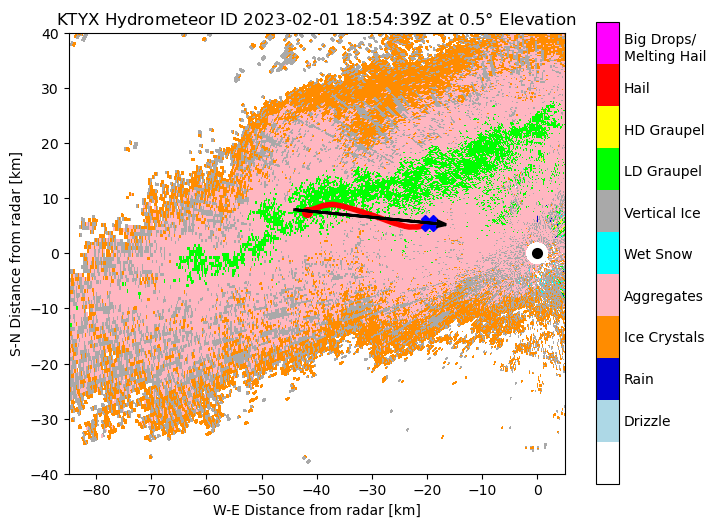

In [25]:
fig, ax3 = plt.subplots(1, 1, figsize=(8, 6))
display = pyart.graph.RadarDisplay(radar)
n_sweep = 0
refl_min = -10
refl_max = 75
hid_min=0
hid_max=10

# pcm4 = ax4.pcolormesh(grid_x-0.5,grid_y-0.5,grid_hid[zlevel,:,:],cmap=cmaphid,vmin=hid_min,vmax=hid_max)
#Make reflectivity PPI panel
display.plot('HID', n_sweep, vmin=hid_min, vmax=hid_max, ax=ax3, cmap=cmaphid)
display.cbs[0] = adjust_fhc_colorbar_for_pyart(display.cbs[0])
ax3.plot(0,0,marker='.',color='black',ms=10,mew=3)
ax3.plot(-41.76619,7.57066,marker='.',color='red',ms=10,mew=3) # PASIV launch site CALCULATED X AND Y DISTS: 41.76619km west ,7.57066 north of radar site

#plot the full flight path
# we need the file with the GPS coordinates for this, read it in
probe_data = pd.read_csv('/Users/ethan1/Desktop/vs_code/NSSL/Hydrometeor_Class/NSSL1_MW41_output_20230201_185158.csv')
# we're going to use the columns 'Filtered Latitude ' and 'Filtered Longitude '
# convert relevant columns only
probe_data['Filtered Latitude ']  = pd.to_numeric(probe_data['Filtered Latitude '], errors='coerce')
probe_data['Filtered Longitude '] = pd.to_numeric(probe_data['Filtered Longitude '], errors='coerce')

# convert to Cartesian (meters)
probe_x, probe_y = pyart.core.geographic_to_cartesian_aeqd(
    probe_data['Filtered Longitude '], 
    probe_data['Filtered Latitude '],
    radar.longitude['data'][0], 
    radar.latitude['data'][0], 
    R=6370997.0
)

# convert to km
probe_x /= 1000.0
probe_y /= 1000.0

# plot once
ax3.plot(probe_x, probe_y, color='red', linewidth=4, label='PASIV Flight Path')
#plot the landing zone in a different color
landing_lat = probe_data['Filtered Latitude '].iloc[-1]
landing_lon = probe_data['Filtered Longitude '].iloc[-1]

landing_x, landing_y = pyart.core.geographic_to_cartesian_aeqd(
    landing_lon,
    landing_lat,
    radar.longitude['data'][0],
    radar.latitude['data'][0],
    R=6370997.0
)

# meters → km
landing_x /= 1000.0
landing_y /= 1000.0

ax3.plot(landing_x, landing_y, marker='X', color='blue', markersize=12, label='Landing Zone')

ax3.set_title('KTYX Hydrometeor ID '+dt.datetime.strftime(radar_starttime,'%Y-%m-%d %H:%M:%SZ at 0.5$\degree$ Elevation'))
ax3.set_xlabel('W-E Distance from radar [km]')
ax3.set_ylabel('S-N Distance from radar [km]')

ax3.set_xlim([-85, 5])
ax3.set_ylim([-40, 40])
ax3.set_aspect("equal", "box")
ax3.arrow(mx, xy, xx-mx, my-xy, head_width=1.0, head_length=1.5,
        color='black', linewidth=2, label='Cross Section Line', zorder=10)

plt.savefig('/Users/ethan1/Desktop/Professional/AMS_2026/KTYX_HID_PPI_20230201_185439Z_0.5deg.png', dpi=300)

# #Make HID colorbar
# pos6 = ax6.get_position()
# cax2 = fig.add_axes([0.92,pos6.y0,0.02,pos6.height])
# cb2 = adjust_fhc_colorbar_for_pyart(plt.colorbar(pcm4, cax=cax2))

Landing: [-19.68807033], [5.5227048]
Launch: [-41.86361817], [7.70478949]


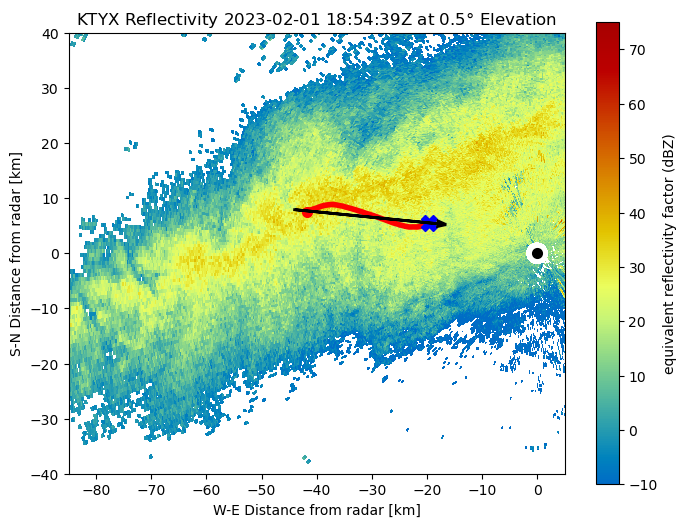

In [26]:
fig, ax4 = plt.subplots(1, 1, figsize=(8, 6))
display2 = pyart.graph.RadarDisplay(radar)

#Make reflectivity PPI panel
display2.plot('reflectivity', n_sweep, vmin=refl_min, vmax=refl_max, ax=ax4, cmap='HomeyerRainbow')
# display2.cbs[0] = adjust_fhc_colorbar_for_pyart(display2.cbs[0])
ax4.plot(0,0,marker='.',color='black',ms=10,mew=3)
ax4.plot(-41.76619,7.57066,marker='.',color='red',ms=10,mew=3) # PASIV launch site CALCULATED X AND Y DISTS: 41.76619km west ,7.57066 north of radar site
# ax4.set_title('Reflectivity at '+"{:4.1f}".format(radar.fixed_angle['data'][n_sweep])+r'$\degree$ Elevation')
ax4.set_xlabel('W-E Distance from radar [km]')
ax4.set_ylabel('S-N Distance from radar [km]')
ax4.set_title('KTYX Reflectivity '+dt.datetime.strftime(radar_starttime,'%Y-%m-%d %H:%M:%SZ at 0.5$\degree$ Elevation'))

#plot the full flight path
# we need the file with the GPS coordinates for this, read it in
probe_data = pd.read_csv('/Users/ethan1/Desktop/vs_code/NSSL/Hydrometeor_Class/NSSL1_MW41_output_20230201_185158.csv')
# we're going to use the columns 'Filtered Latitude ' and 'Filtered Longitude '
# convert relevant columns only
probe_data['Filtered Latitude ']  = pd.to_numeric(probe_data['Filtered Latitude '], errors='coerce')
probe_data['Filtered Longitude '] = pd.to_numeric(probe_data['Filtered Longitude '], errors='coerce')

# convert to Cartesian (meters)
probe_x, probe_y = pyart.core.geographic_to_cartesian_aeqd(
    probe_data['Filtered Longitude '], 
    probe_data['Filtered Latitude '],
    radar.longitude['data'][0], 
    radar.latitude['data'][0], 
    R=6370997.0
)

# convert to km
probe_x /= 1000.0
probe_y /= 1000.0

# plot once
ax4.plot(probe_x, probe_y, color='red', linewidth=4, label='PASIV Flight Path')
#plot the landing zone in a different color
landing_lat = probe_data['Filtered Latitude '].iloc[-1]
landing_lon = probe_data['Filtered Longitude '].iloc[-1]

landing_x, landing_y = pyart.core.geographic_to_cartesian_aeqd(
    landing_lon,
    landing_lat,
    radar.longitude['data'][0],
    radar.latitude['data'][0],
    R=6370997.0
)

# meters → km
landing_x /= 1000.0
landing_y /= 1000.0
print(f"Landing: {landing_x}, {landing_y}")

launch_x, launch_y = pyart.core.geographic_to_cartesian_aeqd(
    probe_data['Filtered Longitude '].iloc[0],
    probe_data['Filtered Latitude '].iloc[0],
    radar.longitude['data'][0],
    radar.latitude['data'][0],
    R=6370997.0
)
# meters → km
launch_x /= 1000.0
launch_y /= 1000.0
print(f"Launch: {launch_x}, {launch_y}")

ax4.plot(landing_x, landing_y, marker='X', color='blue', markersize=12, label='Landing Zone')
ax4.set_xlim([-85, 5])
ax4.set_ylim([-40, 40])
ax4.set_aspect("equal", "box")
ax4.arrow(mx, xy, xx-mx, my-xy, head_width=1.0, head_length=1.5,
        color='black', linewidth=2, label='Cross Section Line', zorder=10)


plt.savefig('/Users/ethan1/Desktop/Professional/AMS_2026/KTYX_REFLECTIVITY_PPI_20230201_185439Z_0.5deg.png', dpi=300)

In [27]:
# step 1: create height bins
height_bins = np.arange(0, 4250, 100)
height_df = final_df.copy() # copy of the final df so we don't mess up the original with all the data
height_df["alt_bin"] = pd.cut(height_df["Filtered Altitude (m) "], bins=height_bins)

# step 2: count classifications per bin
counts = (
    height_df
    .groupby("alt_bin")["classifications"]
    .value_counts()
    .unstack(fill_value=0)
)

#display(height_df) # sanity check

# step 3: convert counts to frequency
freq = counts.div(counts.sum(axis=1), axis=0)

# step 4: compute altitude bin centers for plotting on the y axis
alt_centers = np.array([b.mid for b in freq.index])

# now do the same for RF_Predictions
rf_height_df = final_df.copy()
rf_height_df["rf_alt_bin"] = pd.cut(rf_height_df["Filtered Altitude (m) "], bins=height_bins)

counts = (
    rf_height_df
    .groupby("rf_alt_bin")["RF_Predictions"]
    .value_counts()
    .unstack(fill_value=0)
)

rf_freq = counts.div(counts.sum(axis=1), axis=0)
rf_alt_centers = np.array([b.mid for b in rf_freq.index])

In [28]:
# Make a KD tree for pulling an arbitrary cross section from the radar
des_tree = spatial.KDTree(np.array([radar.gate_x['data'].ravel(),
                                     radar.gate_y['data'].ravel(),
                                     radar.gate_z['data'].ravel()]).T)

In [29]:
(g1_lon, g2_lon, g1_lat, g2_lat,new_x,new_angle,
    edge_x, edge_z, indext, z_grid_shape, dists) = cs_grid(radar, des_tree, mx, xx, my, my)

In [30]:
#########################
# If you have a balloon sounding to work with:
new_sound_x = sound_x_ktyx-mx*1e3
new_sound_y = sound_y_ktyx-my*1e3

new_sound_r     = new_sound_x*np.cos(-new_angle) - new_sound_y*np.sin(-new_angle) # Cartesian x
new_sound_dists = new_sound_y*np.cos(-new_angle) + new_sound_x*np.sin(-new_angle) # Cartesian y
#########################

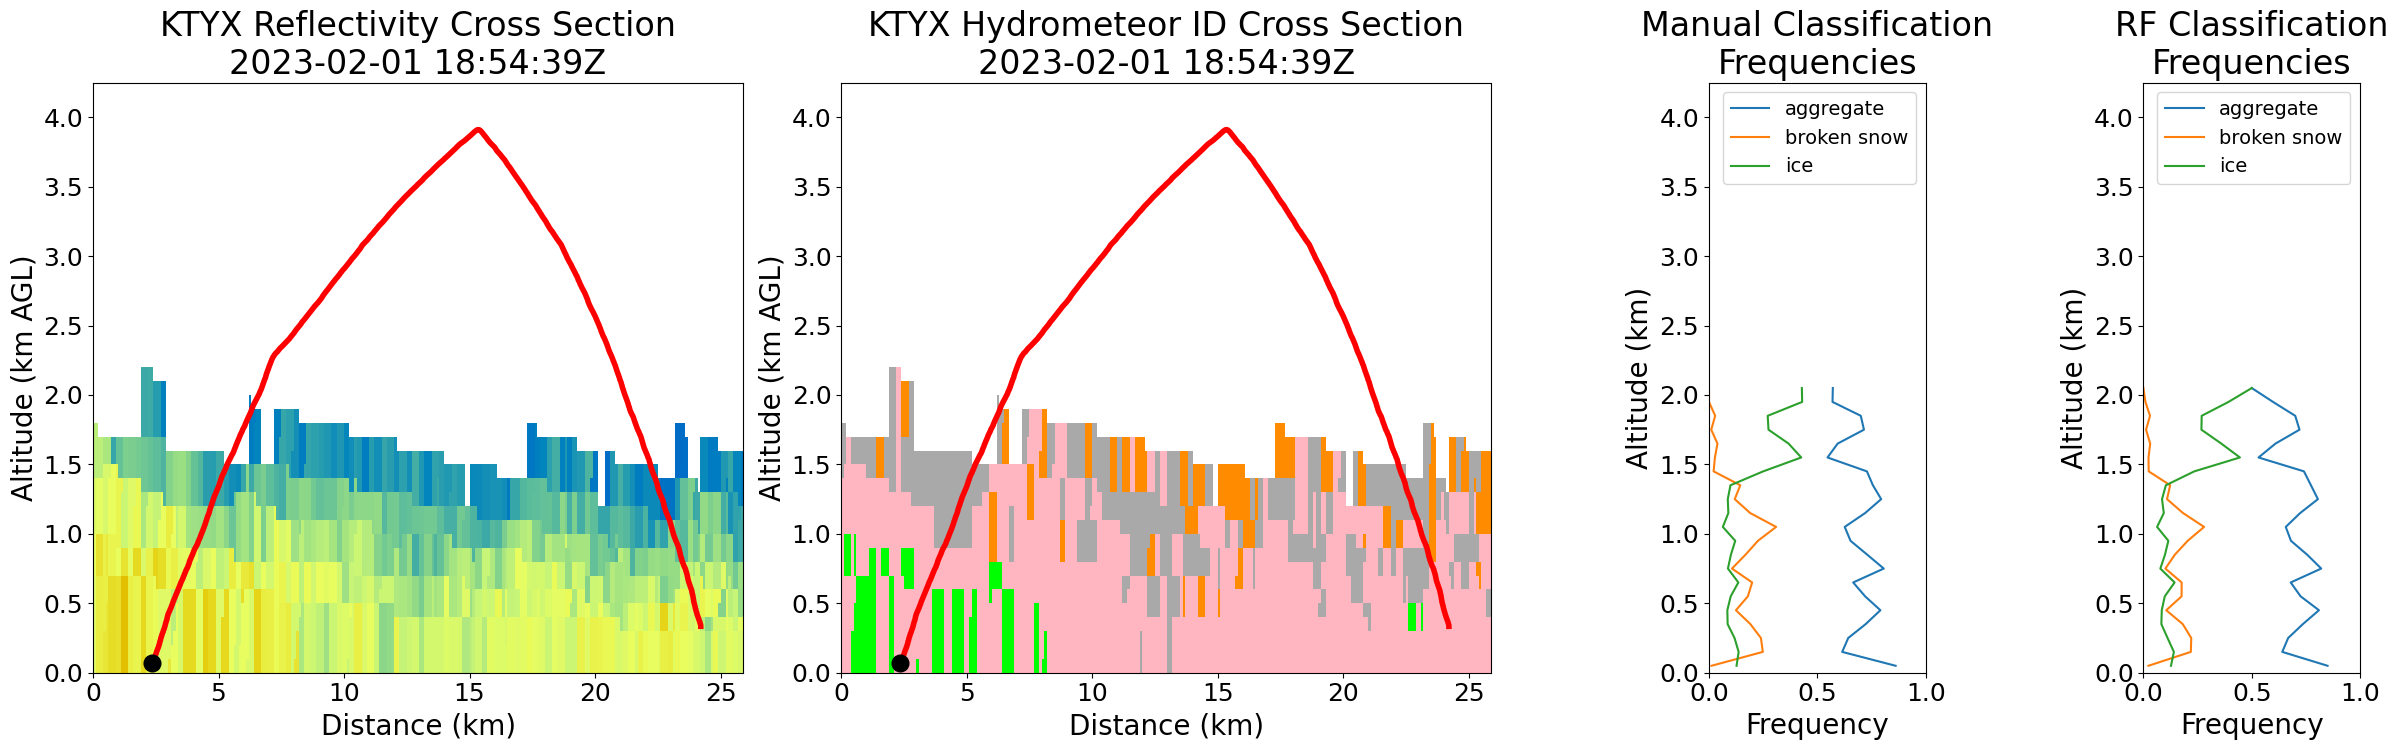

In [31]:
field_of_interest_HID = radar.fields['HID']['data'].ravel()[indext]
field_of_interest_HID = np.ma.masked_where(dists>1500, # Only consider radar gates within 1500 m
                                       field_of_interest_HID)

field_of_interest_REF = radar.fields['reflectivity']['data'].ravel()[indext]
field_of_interest_REF = np.ma.masked_where(dists>1500, # Only consider radar gates within 1500 m
                                       field_of_interest_REF)

# fig, ax = plt.subplots(1, 4, figsize=(24, 8), gridspec_kw={"width_ratios": [3, 3, 1, 1]})  
fig = plt.figure(figsize=(24, 8))

gs = fig.add_gridspec(
    1, 6,
    width_ratios=[3, 3, 0.1, 1, 0.1, 1]  # <- key line
)

ax = [
    fig.add_subplot(gs[0]),  # ax[0] REF
    fig.add_subplot(gs[1]),  # ax[1] HID
    fig.add_subplot(gs[3]),  # ax[2] Manual freq
    fig.add_subplot(gs[5])   # ax[3] RF freq
]

fig.add_subplot(gs[2]).axis("off")  # small gap
fig.add_subplot(gs[4]).axis("off")  # large gap

pcm4 = ax[0].pcolormesh(edge_x/1e3, edge_z/1e3,
                     field_of_interest_REF.reshape(z_grid_shape),
                     cmap='HomeyerRainbow',vmin=-10,vmax=75)

# cb2 = adjust_fhc_colorbar_for_pyart(plt.colorbar(pcm4))

# now we will plot the pasiv path through this cross section
# since this is an arbitrary cross section, we will assume that the horizontal variations in the flight path are negligible in this plot
ax[0].plot(new_sound_r/1e3, sounding['Filtered Altitude (m) ']/1e3, color='red', linewidth=4, label='PASIV Flight Path')
ax[0].plot(new_sound_r[0]/1e3, sounding['Filtered Altitude (m) '][0]/1e3, marker='.', color='black', markersize=24)
# this plots something, idk what, but it works so I'm not touching it
#plt.plot(new_x/1e3)#,g_cs/1e3)
ax[0].set_xlim(0,np.max(new_x)/1e3)
ax[0].set_ylim(0,4.25)
ax[0].set_ylabel('Altitude (km AGL)', fontsize=20)
ax[0].set_xlabel('Distance (km)', fontsize=20)
ax[0].set_title('KTYX Reflectivity Cross Section\n'+dt.datetime.strftime(radar_starttime,
            '%Y-%m-%d %H:%M:%SZ').format(mx, my, xx, xy), fontsize = 24)



pcm4 = ax[1].pcolormesh(edge_x/1e3, edge_z/1e3,
                     field_of_interest_HID.reshape(z_grid_shape),
                     cmap=cmaphid,vmin=hid_min,vmax=hid_max)

# cb2 = adjust_fhc_colorbar_for_pyart(plt.colorbar(pcm4))

# now we will plot the pasiv path through this cross section
# since this is an arbitrary cross section, we will assume that the horizontal variations in the flight path are negligible in this plot
ax[1].plot(new_sound_r/1e3, sounding['Filtered Altitude (m) ']/1e3, color='red', linewidth=4, label='PASIV Flight Path')
ax[1].plot(new_sound_r[0]/1e3, sounding['Filtered Altitude (m) '][0]/1e3, marker='.', color='black', markersize=24)
# this plots something, idk what, but it works so I'm not touching it
#plt.plot(new_x/1e3)#,g_cs/1e3)
ax[1].set_xlim(0,np.max(new_x)/1e3)
ax[1].set_ylim(0,4.25)
ax[1].set_ylabel('Altitude (km AGL)', fontsize=20)
ax[1].set_xlabel('Distance (km)', fontsize=20)
ax[1].set_title('KTYX Hydrometeor ID Cross Section\n'+dt.datetime.strftime(radar_starttime,
            '%Y-%m-%d %H:%M:%SZ').format(mx, my, xx, xy), fontsize = 24)

# now add the frequency plot
smooth_freq = freq.copy()
for cls in freq.columns:
    smooth_freq[cls] = gaussian_filter1d(freq[cls], sigma=0.5)

for cls in freq.columns:
    ax[2].plot(freq[cls], alt_centers, label=f"Class {cls}")

yticks_m = np.arange(0, 4500, 500)
ax[2].set_yticks(yticks_m)

# relabel ticks in km
ax[2].set_yticklabels(yticks_m / 1000)

ax[2].set_ylabel("Altitude (km)", fontsize=20)
ax[2].set_xlabel("Frequency", fontsize=20)
ax[2].legend(['aggregate', 'broken snow', 'ice'], fontsize=14)
ax[2].set_xlim(0, 1)
ax[2].set_ylim(0, 4250)
ax[2].set_title("Manual Classification\nFrequencies", fontsize = 24)

# finally, add the ML classification frequency plot
rf_smooth_freq = rf_freq.copy()
for cls in rf_freq.columns:
    rf_smooth_freq[cls] = gaussian_filter1d(rf_freq[cls], sigma=0.5)

for cls in rf_freq.columns:
    ax[3].plot(rf_freq[cls], rf_alt_centers, label=f"Class {cls}")

yticks_m = np.arange(0, 4500, 500)
ax[3].set_yticks(yticks_m)
ax[3].set_yticklabels(yticks_m / 1000)
ax[3].set_ylabel("Altitude (km)", fontsize=20)
ax[3].set_xlabel("Frequency", fontsize=20)
ax[3].legend(['aggregate', 'broken snow', 'ice'], fontsize=14)
ax[3].set_xlim(0, 1)
ax[3].set_ylim(0, 4250)
ax[3].set_title("RF Classification\nFrequencies", fontsize = 24)

# set all the font sizes
ax[0].tick_params(axis='x', labelsize=18)
ax[0].tick_params(axis='y', labelsize=18)
ax[1].tick_params(axis='x', labelsize=18)
ax[1].tick_params(axis='y', labelsize=18)
ax[2].tick_params(axis='x', labelsize=18)
ax[2].tick_params(axis='y', labelsize=18)
ax[3].tick_params(axis='x', labelsize=18)
ax[3].tick_params(axis='y', labelsize=18)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('/Users/ethan1/Desktop/Professional/AMS_2026/KTYX_Cross_Section.png', dpi=300)
plt.show()
